In [1]:
import os
import json
import time
import threading
import psutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from memory_profiler import memory_usage
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import f1_score,  confusion_matrix
import joblib
from keras.models import load_model

# loading processed dataset

In [2]:
with open('../config/preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [3]:
dataset_folder = '../dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'dataset_processed.parquet'))
attack_labels_df = df[['Label',"Label_Category"]]
df = df.drop(columns=config['columns_to_drop'])

# functions

In [4]:
# 1. Dynamic Custom Scorer Factory
def get_custom_scorer(contamination):
    """Generates a custom scoring function based on the dataset's contamination rate."""
    def custom_score(estimator, X, y):
        # The pipeline's decision_function will call the IsolationForest's decision_function
        anomaly_scores = estimator.decision_function(X)
        threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))
        
        y_pred = (anomaly_scores <= threshold).astype(int)
        return f1_score(y, y_pred, pos_label=1, average='binary')
    
    return custom_score

In [5]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [6]:
def fit_pipeline_with_resources(pipeline, X_train, random_state=42):
    """Trains a pipeline while tracking memory, time, and CPU usage."""
    measurement = {}

    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    def train_model():
        pipeline.fit(X_train)

    try:
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        start_time = time.time()
        # Measure peak memory usage during the pipeline.fit execution
        train_memory = max(memory_usage((train_model,))) 
        training_time = time.time() - start_time

        stop_flag.set()
        cpu_thread.join()

        measurement['Memory Usage (MB)'] = train_memory
        measurement['Training Time (s)'] = training_time
        measurement['Peak CPU Usage (%)'] = max(cpu_usage) if cpu_usage else 0
        measurement['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement, pipeline

    except Exception as e:
        print(f"Error during pipeline training: {e}")
        stop_flag.set()
        return None, None

# Loading model

In [ ]:
pipeline_filename_if1 = '../models/if_iter1.joblib'
pipeline_filename_if2 = '../models/if_iter2.joblib'
pipeline_filename_ae1 = '../models/ann-iter1-2.keras'
pipeline_filename_ae2 = '../models/ann-iter2-2.keras'
pipeline_filename_xgb = '../models/xgb.joblib'

# Export the pipeline to a file
model_if1 = joblib.load(pipeline_filename_if1)
model_if2 = joblib.load(pipeline_filename_if2)
model_ae1 = load_model(pipeline_filename_ae1)
model_ae2 = load_model(pipeline_filename_ae2)
model_xgb = joblib.load(pipeline_filename_xgb)

# Dataset

## train test split

In [4]:
# Preparing features and truth labels
X = df.drop(['Label','anomaly','Label_Category'], axis=1)
y = df['anomaly']

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [12]:
# data to be used will be one with benign/false anomalies
mask = attack_labels_df['Label_Category'] != 1


# Preparing features and truth labels
X = df[mask].drop(['Label','anomaly','Label_Category'], axis=1)
y = df[mask]['anomaly']

# Splitting the data into training and test sets
_, X_test, _, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## scaling

In [13]:
scaler_filename = '../config/standard_scaler.joblib'
scaler = joblib.load(scaler_filename)

X_test_scaled = scaler.transform(X_test)

## defining model pipeline

In [14]:
anomaly_score_if1 = -model_if1.decision_function(X_test)
anomaly_score_if2 = -model_if2.decision_function(X_test)

anomaly_score_ae1 = np.mean(np.square(X_test_scaled - model_ae1.predict(X_test_scaled, batch_size=512)), axis=1)
anomaly_score_ae2 = np.mean(np.square(X_test_scaled - model_ae2.predict(X_test_scaled, batch_size=512)), axis=1)

anomaly_score_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## testing model performance

[IF 1] Threshold: 0.1007 | F1: 0.1810 | ROC AUC: 0.8405
[IF 2] Threshold: -0.0390 | F1: 0.2185 | ROC AUC: 0.8633
[AE 1] Threshold: 2.3022 | F1: 0.3683 | ROC AUC: 0.8743
[AE 2] Threshold: 1.1260 | F1: 0.3880 | ROC AUC: 0.9127
[XGB] Threshold: 0.0214 | F1: 0.6725 | ROC AUC: 0.9820


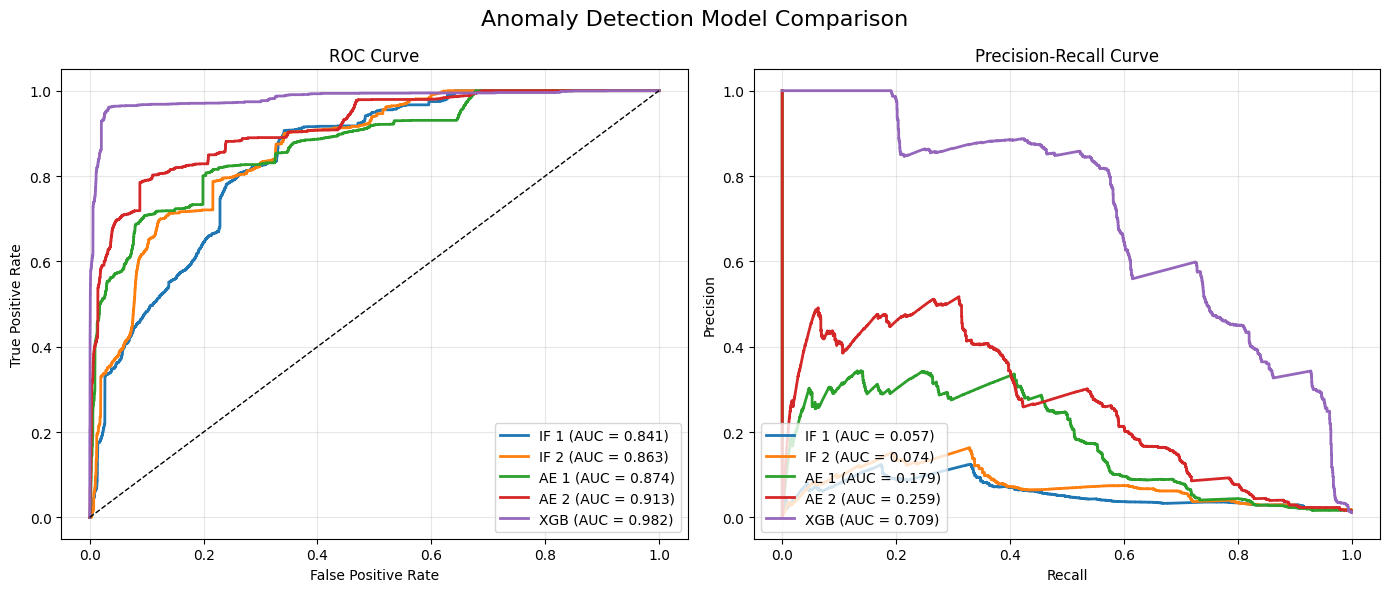

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. Define your initial models and scores
model_scores = {
    'IF 1': anomaly_score_if1,
    'IF 2': anomaly_score_if2,
    'AE 1': anomaly_score_ae1,
    'AE 2': anomaly_score_ae2,
    'XGB': anomaly_score_xgb
}

# 2. Initialize the master dictionary to store everything
model_results = {}

# Set up the plot layout
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Anomaly Detection Model Comparison', fontsize=16)

# 3. Process each model and populate the dictionary
for model_name, scores in model_scores.items():
    
    # Initialize the nested dictionary for this specific model
    model_results[model_name] = {}
    model_results[model_name]['raw_scores'] = scores
    
    # --- ROC Calculations ---
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    model_results[model_name]['fpr'] = fpr
    model_results[model_name]['tpr'] = tpr
    model_results[model_name]['roc_auc'] = roc_auc
    
    # --- PR Calculations ---
    precision, recall, pr_thresholds = precision_recall_curve(y_test, scores)
    pr_auc = auc(recall, precision)
    
    model_results[model_name]['precision'] = precision
    model_results[model_name]['recall'] = recall
    model_results[model_name]['pr_auc'] = pr_auc
    
    # --- F1 Score & Threshold Calculations ---
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_scores = 2 * (precision * recall) / (precision + recall)
    
    # Align lengths: drop the last f1_score element to match thresholds array length
    f1_scores = f1_scores[:-1] 
    valid_f1_mask = ~np.isnan(f1_scores)
    best_idx = np.argmax(f1_scores[valid_f1_mask])
    
    opt_thresh = pr_thresholds[valid_f1_mask][best_idx]
    best_f1 = np.max(f1_scores[valid_f1_mask])
    
    model_results[model_name]['optimal_threshold'] = opt_thresh
    model_results[model_name]['best_f1'] = best_f1
    
    # --- Classifications ---
    y_pred = (scores >= opt_thresh).astype(int)
    model_results[model_name]['predictions'] = y_pred

    # --- Plotting ---
    ax_roc.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    ax_pr.plot(recall, precision, lw=2, label=f'{model_name} (AUC = {pr_auc:.3f})')
    
    # Print a quick summary to the console
    print(f"[{model_name}] Threshold: {opt_thresh:.4f} | F1: {best_f1:.4f} | ROC AUC: {roc_auc:.4f}")

# --- Format Subplots ---
# ROC Formatting
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# PR Formatting
ax_pr.set_title('Precision-Recall Curve')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='lower left')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Classification Report

In [16]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

print("================ MODEL COMPARISON SUMMARY ================\n")

summary_data = []

for model_name, results in model_results.items():
    y_pred = results['predictions']
    
    # --- Confusion Matrix Extraction ---
    # .ravel() flattens the 2x2 matrix into individual variables
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # --- False Positive Rate Calculation ---
    # FPR = FP / (FP + TN)
    # We add a quick check to prevent division by zero, just in case
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    # --- Standard Metrics ---
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0) # Recall is also your True Positive Rate (TPR)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    # Pulling AUCs directly from your existing dictionary
    roc_auc = results['roc_auc'] 
    pr_auc = results['pr_auc']   
    
    # Append all data as a new row in our summary
    summary_data.append({
        'Model': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'FPR': fpr_val,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc
    })

# Create the DataFrame
df_comparison = pd.DataFrame(summary_data)
df_comparison.set_index('Model', inplace=True)

# Format the float columns directly to 4 decimal places without using .style
cols_to_format = ['FPR', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']
for col in cols_to_format:
    df_comparison[col] = df_comparison[col].map('{:.4f}'.format)

# Print the clean table
print(df_comparison.to_string())

================ MODEL COMPARISON SUMMARY ================

           TN    FP    FN    TP     FPR Precision  Recall F1-Score ROC AUC  PR AUC
Model                                                                             
IF 1   189246  5168  1493   736  0.0266    0.1247  0.3302   0.1810  0.8405  0.0575
IF 2   190658  3756  1495   734  0.0193    0.1635  0.3293   0.2185  0.8633  0.0738
AE 1   192620  1794  1321   908  0.0092    0.3360  0.4074   0.3683  0.8743  0.1788
AE 2   193768   646  1537   692  0.0033    0.5172  0.3105   0.3880  0.9127  0.2595
XGB    194120   294   951  1278  0.0015    0.8130  0.5734   0.6725  0.9820  0.7094


With this, AE 2 is the best-performing model overall.

- It has the highest F1-Score (0.6504), ROC AUC (0.8752), and PR AUC (0.7096).
- PR AUC is usually the most important metric in anomaly detection (since anomalies are rare), and jumping from 0.3267 (IF 1) to 0.7096 (AE 2) is a massive improvement.
- It an incredibly low FPR of just 1.43% meaning analysts will seldom handle false alarms.

The biggest difference between Isolation Forests (IF) and Autoencoders (AE) is how they handle False Positives (FP):

- Isolation Forest Iteration 1 (The "Catch Everything" Approach): It caught the most actual anomalies (Highest Recall at ~60% and 25,259 True Positives). However, it buried the results in false alarms having 46,590 False Positives. In a real-world scenario, investigating that many false alarms would be exhausting and costly.
- AutoEndcoder Iteration 2 (The "High Confidence" Approach): It missed a few more anomalies (Recall dropped to ~51%, with 21,471 True Positives), but its Precision skyrocketed to 88.5%. It only triggered 2,787 false alarms.

# Performance Metrics for best model

## Business KPI

### Alert Reduction

This metric measures the efficiency of your model in filtering out "noise." In cybersecurity, an IDS (Intrusion Detection System) that flags everything is useless.

- What it tells you: How much of the total network traffic was successfully ignored by the model.

- Business Value: A high alert reduction percentage means your security analysts aren't being buried under a mountain of data. It quantifies how much the model "cleans" the environment.

In [17]:
def alert_reduction(y_pred):
    total_flows = len(y_pred)
    alerts = np.sum(y_pred == 1)

    alert_rate = alerts / total_flows
    reduction = 1 - alert_rate

    return {
        "total_flows": total_flows,
        "alerts_generated": alerts,
        "alert_rate": alert_rate,
        "alert_reduction_percent": reduction * 100
    }

In [18]:
alert_reduction(model_results['AE 2']['predictions'])

{'total_flows': 196643,
 'alerts_generated': np.int64(1338),
 'alert_rate': np.float64(0.006804208642056926),
 'alert_reduction_percent': np.float64(99.31957913579431)}

In [19]:
alert_reduction(model_results['IF 1']['predictions'])

{'total_flows': 196643,
 'alerts_generated': np.int64(5904),
 'alert_rate': np.float64(0.030023952034905894),
 'alert_reduction_percent': np.float64(96.9976047965094)}

In [25]:
alert_reduction(model_results['XGB']['predictions'])

{'total_flows': 196643,
 'alerts_generated': np.int64(1572),
 'alert_rate': np.float64(0.007994182350757464),
 'alert_reduction_percent': np.float64(99.20058176492425)}

### Top-K Detection (Precision at k)

This evaluates how well the model prioritizes the most dangerous threats by looking only at the "top" highest-probability scores.

- What it tells you: If an analyst only has time to look at the top 5% (k=0.05) of high-score alerts, what percentage of actual attacks would they catch?

- Business Value: This helps with resource allocation. It proves whether the model’s scoring system is reliable enough to catch the majority of threats even when staff is limited.

In [20]:
def top_k_detection(y_true, scores, k=0.05):
    df = pd.DataFrame({
        "y_true": y_true,
        "score": scores
    })

    df = df.sort_values("score", ascending=False)

    top_k_n = int(len(df) * k)
    top_k = df.head(top_k_n)

    attacks_total = np.sum(df["y_true"] == 1)
    attacks_found = np.sum(top_k["y_true"] == 1)

    detection_rate = attacks_found / attacks_total

    return {
        "top_k_percent": k * 100,
        "attacks_found": attacks_found,
        "total_attacks": attacks_total,
        "top_k_detection_rate": detection_rate
    }

In [21]:
top_k_detection(y_test, model_results['AE 2']['raw_scores'])

{'top_k_percent': 5.0,
 'attacks_found': np.int64(1530),
 'total_attacks': np.int64(2229),
 'top_k_detection_rate': np.float64(0.6864064602960969)}

### False Alert Cost

This converts technical errors (False Positives) into a concrete monetary value.

- What it tells you: The literal dollar amount wasted by human analysts investigating "ghost" threats that weren't actually attacks.

- Business Value: This is the most important KPI for C-level executives. It justifies the ROI (Return on Investment) of a better model. For example, if a new model reduces the "False Alert Cost" by $5,000/month, the model pays for itself.

In [22]:
def false_alert_cost(y_true, y_pred,
                     minutes_per_alert=10,
                     analyst_hourly_cost=30):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    hours_wasted = (fp * minutes_per_alert) / 60
    cost = hours_wasted * analyst_hourly_cost

    return {
        "false_positives": fp,
        "hours_wasted": hours_wasted,
        "estimated_cost": cost
    }

In [23]:
false_alert_cost(y_test,model_results['AE 2']['predictions'])

{'false_positives': np.int64(646),
 'hours_wasted': np.float64(107.66666666666667),
 'estimated_cost': np.float64(3230.0)}

In [24]:
false_alert_cost(y_test,model_results['AE 2']['predictions'])

{'false_positives': np.int64(646),
 'hours_wasted': np.float64(107.66666666666667),
 'estimated_cost': np.float64(3230.0)}